# Multilabel Model Comparison

Compare all methods on the same unchanged real test set.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "multilabel"

metric_files = [
    "baseline_metrics.csv",
    "weighted_metrics.csv",
    "oversampling_metrics.csv",
    "vae_augmented_metrics.csv",
    "gan_augmented_metrics.csv",
]

comparison = pd.concat(
    [pd.read_csv(PROCESSED_DIR / filename) for filename in metric_files],
    ignore_index=True,
)
comparison.round(4)

,Model,Exact Match Accuracy,Hamming Loss,Micro F1,Macro F1,Surface Crack F1,Delamination F1,Pinhole F1
0,Baseline,0.9300,0.0278,0.9664,0.9292,0.9856,0.8800,0.9220
1,Weighted BCE,0.8800,0.0456,0.9458,0.9129,0.9727,0.8980,0.8679
2,Oversampling,0.9233,0.0278,0.9663,0.9362,0.9816,0.8936,0.9333
3,VAE Augmentation,0.9033,0.0367,0.9545,0.8816,0.9760,0.7317,0.9371
4,GAN Augmentation,0.9267,0.0289,0.9647,0.8847,0.9909,0.7317,0.9315


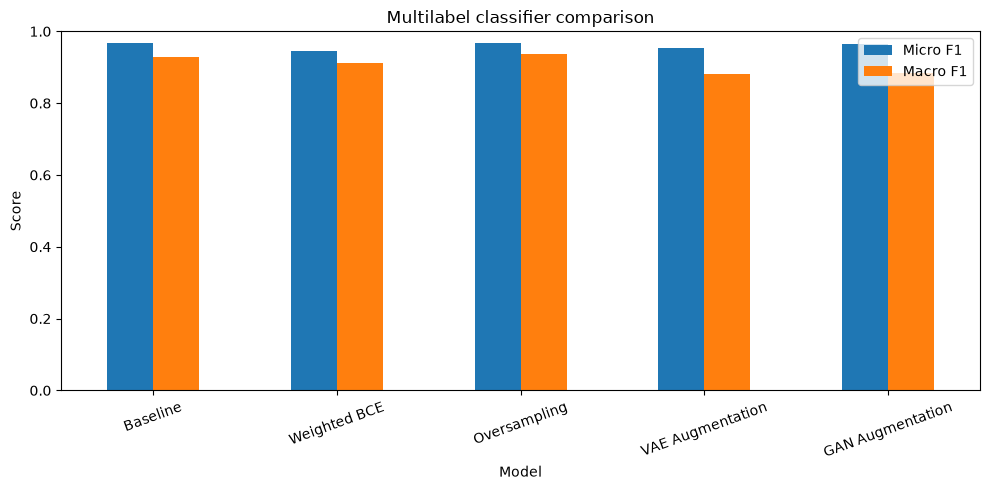

In [2]:
comparison.set_index("Model")[["Micro F1", "Macro F1"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1)
)
plt.ylabel("Score")
plt.title("Multilabel classifier comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [3]:
comparison.to_csv(PROCESSED_DIR / "model_comparison.csv", index=False)
best_model = comparison.loc[comparison["Macro F1"].idxmax()]
print("Best macro-F1 method:", best_model["Model"])
print("Macro F1:", round(best_model["Macro F1"], 4))
print()
print("Remember: synthetic quality and downstream metrics must be discussed together.")

Best macro-F1 method: Oversampling
Macro F1: 0.9362

Remember: synthetic quality and downstream metrics must be discussed together.


## Reporting guidance

For this five-epoch comparison, oversampling produced the best macro F1 (0.9362), while the plain baseline produced the best exact-match accuracy (0.9300). Weighted BCE improved Delamination F1, but reduced Pinhole F1 and overall exact-match accuracy.

The VAE and GAN samples did not improve macro F1 in this short run. This is still a useful result: the synthetic images should not be described as successful augmentation unless visual inspection and repeated classifier experiments support that claim. Try longer generator training and tune the amount of synthetic data as later experiments.

Do not compare these numbers directly with the old single-label scores. Multilabel classification is a different prediction task. Report all five methods using the same real test set, and note that results from a single seed are preliminary.